# 🔍 Data Quality Check — Datathon 2026
**Mục tiêu:** Kiểm tra toàn diện chất lượng 14 file CSV trước khi EDA sâu hơn.

Bao gồm:
- Shape & dtypes
- Missing values
- Duplicates
- Outliers (numerical)
- Cardinality (categorical)
- Referential integrity giữa các bảng (FK checks)
- Kiểm tra logic nghiệp vụ (business rules)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

INPUT_DIR = Path('input')  # <-- đổi đường dẫn nếu cần

# Màu sắc nhất quán
COLOR_MISSING  = '#E24B4A'
COLOR_OK       = '#1D9E75'
COLOR_WARN     = '#EF9F27'
COLOR_NEUTRAL  = '#888780'

print('✅ Imports OK')

✅ Imports OK


## 1. Load tất cả 14 file CSV

In [ ]:
FILE_CONFIGS = {
    'products'       : {'pk': 'product_id',  'date_cols': []},
    'customers'      : {'pk': 'customer_id', 'date_cols': ['signup_date']},
    'promotions'     : {'pk': 'promo_id',    'date_cols': ['start_date', 'end_date']},
    'geography'      : {'pk': 'zip',         'date_cols': []},
    'orders'         : {'pk': 'order_id',    'date_cols': ['order_date']},
    'order_items'    : {'pk': None,          'date_cols': []},
    'payments'       : {'pk': 'order_id',    'date_cols': []},
    'shipments'      : {'pk': 'order_id',    'date_cols': ['ship_date', 'delivery_date']},
    'returns'        : {'pk': 'return_id',   'date_cols': ['return_date']},
    'reviews'        : {'pk': 'review_id',   'date_cols': ['review_date']},
    'inventory'      : {'pk': None,          'date_cols': ['snapshot_date']},
    'web_traffic'    : {'pk': None,          'date_cols': ['date']},
    'sales'          : {'pk': None,          'date_cols': ['Date']},
    'sample_submission': {'pk': None,        'date_cols': ['Date']},
}

dfs = {}
load_errors = []

for name, cfg in FILE_CONFIGS.items():
    path = INPUT_DIR / f'{name}.csv'
    try:
        df = pd.read_csv(
            path,
            parse_dates=cfg['date_cols'] if cfg['date_cols'] else False,
            low_memory=False
        )
        dfs[name] = df
        print(f'  ✅ {name:<22} {df.shape[0]:>8,} rows  x  {df.shape[1]:>3} cols')
    except FileNotFoundError:
        load_errors.append(name)
        print(f'  ❌ {name} — FILE NOT FOUND tại {path}')
    except Exception as e:
        load_errors.append(name)
        print(f'  ⚠️  {name} — LỖI: {e}')

print(f'\nLoaded {len(dfs)}/14 files.')

  ✅ products                  2,412 rows  x    8 cols
  ✅ customers               121,930 rows  x    7 cols
  ✅ promotions                   50 rows  x   10 cols
  ✅ geography                39,948 rows  x    4 cols
  ✅ orders                  646,945 rows  x    8 cols
  ✅ order_items             714,669 rows  x    7 cols
  ✅ payments                646,945 rows  x    4 cols
  ✅ shipments               566,067 rows  x    4 cols
  ✅ returns                  39,939 rows  x    7 cols
  ✅ reviews                 113,551 rows  x    7 cols
  ✅ inventory                60,247 rows  x   17 cols
  ✅ web_traffic               3,652 rows  x    7 cols
  ✅ sales                     3,833 rows  x    3 cols
  ✅ sample_submission           548 rows  x    3 cols

Loaded 14/14 files.


In [5]:
# ============================================================
# SCHEMA CHECK — So sánh cột thực tế vs mô tả ban tổ chức
# ============================================================

EXPECTED_COLS = {
    'products'    : ['product_id','product_name','category','segment','size','color','price','cogs'],
    'customers'   : ['customer_id','zip','city','signup_date','gender','age_group','acquisition_channel'],
    'promotions'  : ['promo_id','promo_name','promo_type','discount_value','start_date','end_date',
                     'applicable_category','promo_channel','stackable_flag','min_order_value'],
    'geography'   : ['zip','city','region','district'],
    'orders'      : ['order_id','order_date','customer_id','zip','order_status',
                     'payment_method','device_type','order_source'],
    'order_items' : ['order_id','product_id','quantity','unit_price','discount_amount','promo_id','promo_id_2'],
    'payments'    : ['order_id','payment_method','payment_value','installments'],
    'shipments'   : ['order_id','ship_date','delivery_date','shipping_fee'],
    'returns'     : ['return_id','order_id','product_id','return_date','return_reason',
                     'return_quantity','refund_amount'],
    'reviews'     : ['review_id','order_id','product_id','customer_id','review_date','rating','review_title'],
    'inventory'   : ['snapshot_date','product_id','stock_on_hand','units_received','units_sold',
                     'stockout_days','days_of_supply','fill_rate','stockout_flag','overstock_flag',
                     'reorder_flag','sell_through_rate'],
    'web_traffic' : ['date','sessions','unique_visitors','page_views','bounce_rate',
                     'avg_session_duration_sec','conversion_rate','traffic_source'],
    'sales'       : ['Date','Revenue','COGS'],
    'sample_submission': ['Date','Revenue'],  # điều chỉnh nếu cần
}

print('='*70)
print(f"{'Table':<22} {'Status':<8} Chi tiết")
print('='*70)

all_ok = True
for name, expected in EXPECTED_COLS.items():
    if name not in dfs:
        print(f"⚠️  {name:<22} SKIP     (chưa load được)")
        continue

    actual   = list(dfs[name].columns)
    expected_set = set(c.lower() for c in expected)
    actual_set   = set(c.lower() for c in actual)

    missing_cols = expected_set - actual_set   # có trong mô tả nhưng không có trong file
    extra_cols   = actual_set - expected_set   # có trong file nhưng không có trong mô tả
    wrong_order  = (actual_set == expected_set) and (
                   [c.lower() for c in actual] != [c.lower() for c in expected])

    if not missing_cols and not extra_cols:
        print(f"✅  {name:<22} OK      ({len(actual)} cols)")
    else:
        all_ok = False
        print(f"🔴  {name:<22} LỆCH")
        if missing_cols:
            print(f"    ↳ Thiếu (trong mô tả nhưng file không có) : {sorted(missing_cols)}")
        if extra_cols:
            print(f"    ↳ Thừa  (file có nhưng mô tả không nhắc)  : {sorted(extra_cols)}")
        print(f"    ↳ Thực tế  : {actual}")
        print(f"    ↳ Mô tả BTC: {expected}")

print('='*70)
print("✅ Tất cả schema khớp!" if all_ok else "⚠️  Có bảng lệch schema — kiểm tra lại trước khi vẽ ERD.")

Table                  Status   Chi tiết
✅  products               OK      (8 cols)
✅  customers              OK      (7 cols)
✅  promotions             OK      (10 cols)
✅  geography              OK      (4 cols)
✅  orders                 OK      (8 cols)
✅  order_items            OK      (7 cols)
✅  payments               OK      (4 cols)
✅  shipments              OK      (4 cols)
✅  returns                OK      (7 cols)
✅  reviews                OK      (7 cols)
🔴  inventory              LỆCH
    ↳ Thừa  (file có nhưng mô tả không nhắc)  : ['category', 'month', 'product_name', 'segment', 'year']
    ↳ Thực tế  : ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
    ↳ Mô tả BTC: ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'da

In [6]:
# ============================================================
# IN SCHEMA THỰC TẾ — dùng để vẽ ERD sau khi đã confirm
# ============================================================

print("-- Schema thực tế từ CSV (dùng để vẽ ERD)\n")
for name, df in dfs.items():
    print(f"[{name}]  ({len(df):,} rows)")
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_null = df[col].isnull().sum()
        null_str = f"  nullable={n_null:,}" if n_null > 0 else ""
        print(f"    {col:<35} {dtype}{null_str}")
    print()

-- Schema thực tế từ CSV (dùng để vẽ ERD)

[products]  (2,412 rows)
    product_id                          int64
    product_name                        object
    category                            object
    segment                             object
    size                                object
    color                               object
    price                               float64
    cogs                                float64

[customers]  (121,930 rows)
    customer_id                         int64
    zip                                 int64
    city                                object
    signup_date                         datetime64[ns]
    gender                              object
    age_group                           object
    acquisition_channel                 object

[promotions]  (50 rows)
    promo_id                            object
    promo_name                          object
    promo_type                          object
    discount_value       

## 2. Overview tổng hợp — Shape & Memory

In [3]:
summary_rows = []
for name, df in dfs.items():
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    summary_rows.append({
        'Table'  : name,
        'Rows'   : f'{df.shape[0]:,}',
        'Cols'   : df.shape[1],
        'Memory' : f'{mem_mb:.1f} MB',
        'Null %' : f'{df.isnull().mean().mean()*100:.1f}%',
    })

pd.DataFrame(summary_rows).set_index('Table')

,Rows,Cols,Memory,Null %
Table,,,,
products,"2,412",8,0.7 MB,0.0%
customers,"121,930",7,30.5 MB,0.0%
promotions,50,10,0.0 MB,8.0%
geography,"39,948",4,7.2 MB,0.0%
orders,"646,945",8,170.7 MB,0.0%
order_items,"714,669",7,81.8 MB,23.0%
payments,"646,945",4,53.0 MB,0.0%
shipments,"566,067",4,18.1 MB,0.0%
returns,"39,939",7,6.4 MB,0.0%


## 3. Missing Values — Chi tiết từng bảng

In [4]:
def missing_report(df, name):
    total = len(df)
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if miss.empty:
        print(f'  [{name}] ✅ Không có missing values')
        return None
    report = pd.DataFrame({
        'Missing Count': miss,
        'Missing %'   : (miss / total * 100).round(2)
    })
    return report

all_missing = {}
for name, df in dfs.items():
    r = missing_report(df, name)
    if r is not None:
        all_missing[name] = r

# In report
for name, report in all_missing.items():
    print(f'\n📋 {name}')
    print(report.to_string())

  [products] ✅ Không có missing values
  [customers] ✅ Không có missing values
  [geography] ✅ Không có missing values
  [orders] ✅ Không có missing values
  [payments] ✅ Không có missing values
  [shipments] ✅ Không có missing values
  [returns] ✅ Không có missing values
  [reviews] ✅ Không có missing values
  [inventory] ✅ Không có missing values
  [web_traffic] ✅ Không có missing values
  [sales] ✅ Không có missing values
  [sample_submission] ✅ Không có missing values

📋 promotions
                     Missing Count  Missing %
applicable_category             40      80.00

📋 order_items
            Missing Count  Missing %
promo_id_2         714463      99.97
promo_id           438353      61.34


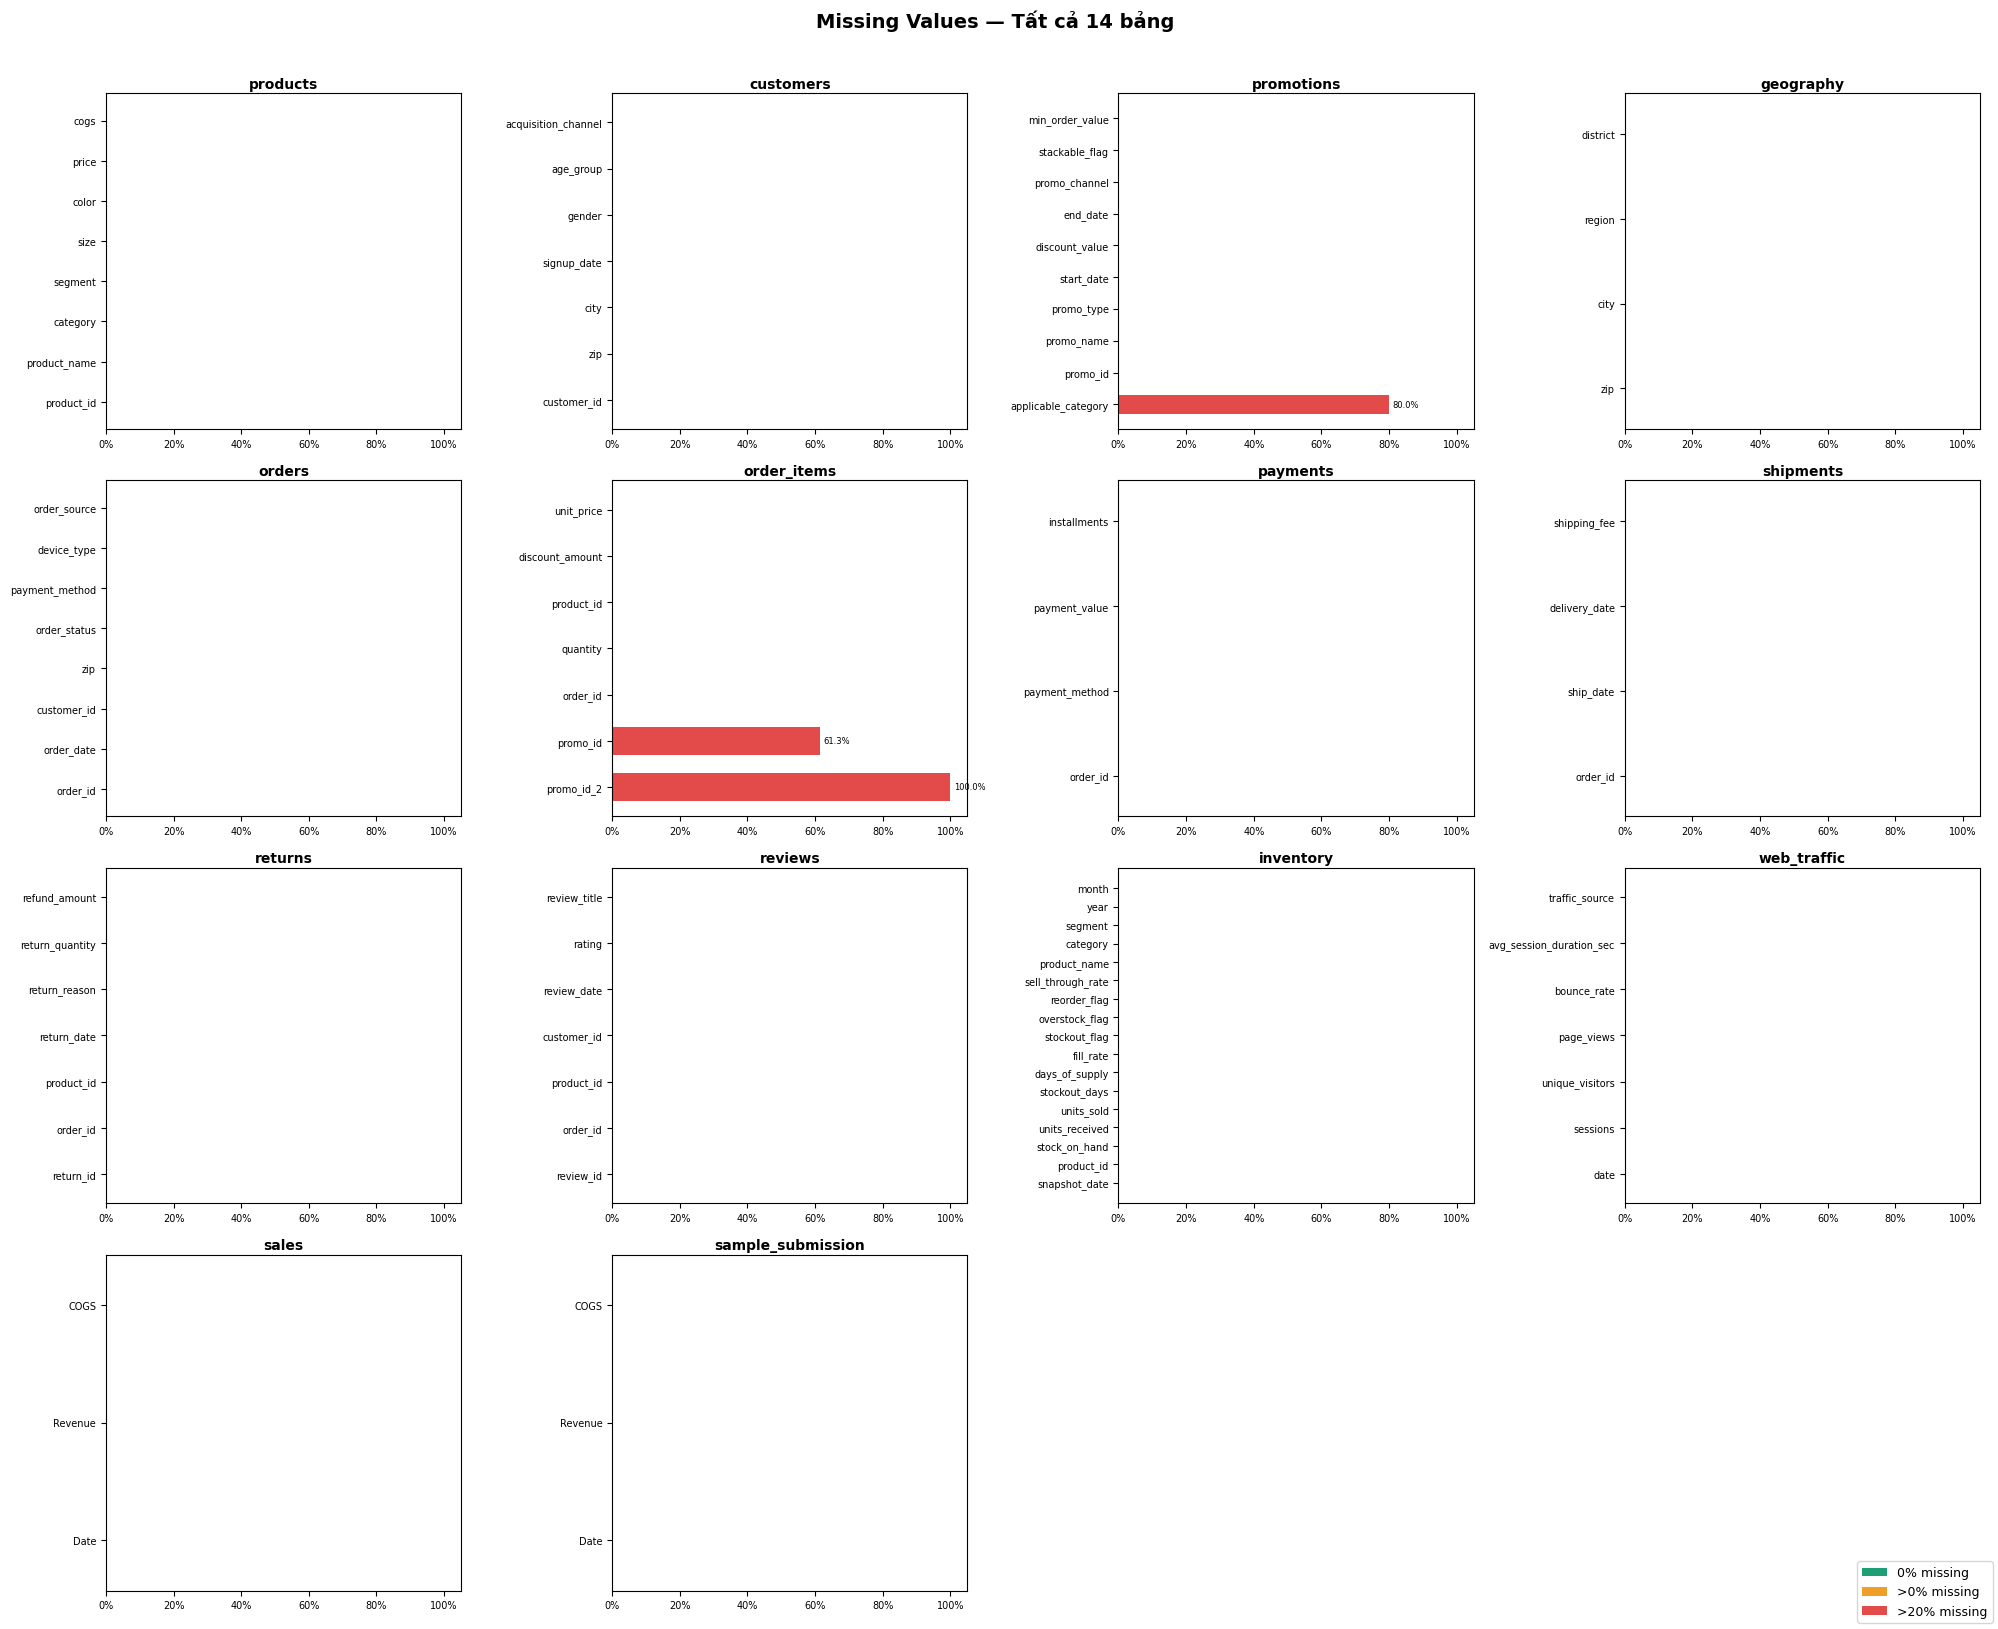

In [5]:
# Heatmap missing values tổng hợp
fig, axes = plt.subplots(
    nrows=4, ncols=4,
    figsize=(20, 16)
)
axes = axes.flatten()

for i, (name, df) in enumerate(dfs.items()):
    ax = axes[i]
    miss_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    colors = [COLOR_MISSING if v > 20 else COLOR_WARN if v > 0 else COLOR_OK for v in miss_pct]
    bars = ax.barh(miss_pct.index, miss_pct.values, color=colors, height=0.6)
    ax.set_xlim(0, 105)
    ax.set_title(name, fontsize=10, fontweight='bold', pad=4)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    for bar, val in zip(bars, miss_pct.values):
        if val > 0:
            ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', ha='left', fontsize=6)

# Ẩn axes thừa
for j in range(len(dfs), len(axes)):
    axes[j].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_OK,      label='0% missing'),
    Patch(facecolor=COLOR_WARN,    label='>0% missing'),
    Patch(facecolor=COLOR_MISSING, label='>20% missing'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9)
fig.suptitle('Missing Values — Tất cả 14 bảng', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Duplicate Check — Primary Keys

In [6]:
print('='*55)
print(f'{'Table':<22} {'PK Column':<18} {'Dup Rows':>8} {'Dup %':>7}')
print('='*55)

dup_results = []
for name, cfg in FILE_CONFIGS.items():
    if name not in dfs:
        continue
    df = dfs[name]
    pk = cfg['pk']

    # Duplicate toàn bộ row
    dup_rows = df.duplicated().sum()
    dup_pct  = dup_rows / len(df) * 100

    # Duplicate theo PK (nếu có)
    pk_dup = 0
    if pk and pk in df.columns:
        pk_dup = df[pk].duplicated().sum()

    flag = '🔴' if dup_rows > 0 or pk_dup > 0 else '✅'
    print(f'{flag} {name:<20} {str(pk):<18} {dup_rows:>8,}  {dup_pct:>6.2f}%'
          + (f'  [PK dup: {pk_dup:,}]' if pk_dup > 0 else ''))

print('='*55)

Table                  PK Column          Dup Rows   Dup %
✅ products             product_id                0    0.00%
✅ customers            customer_id               0    0.00%
✅ promotions           promo_id                  0    0.00%
✅ geography            zip                       0    0.00%
✅ orders               order_id                  0    0.00%
✅ order_items          None                      0    0.00%
✅ payments             order_id                  0    0.00%
✅ shipments            order_id                  0    0.00%
✅ returns              return_id                 0    0.00%
✅ reviews              review_id                 0    0.00%
✅ inventory            None                      0    0.00%
✅ web_traffic          None                      0    0.00%
✅ sales                None                      0    0.00%
✅ sample_submission    None                      0    0.00%


## 5. Data Types & Cardinality — Categorical columns

In [7]:
for name, df in dfs.items():
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if not cat_cols:
        continue
    print(f'\n📋 {name}')
    for col in cat_cols:
        n_unique = df[col].nunique()
        top3 = df[col].value_counts().head(3).index.tolist()
        top3_str = ' | '.join([str(x) for x in top3])
        print(f'   {col:<30} {n_unique:>6,} unique  →  top3: {top3_str}')


📋 products
   product_name                    2,172 unique  →  top3: VietMode RP-02 | VietMode RP-03 | VietMode RP-04
   category                            4 unique  →  top3: Streetwear | Outdoor | Casual
   segment                             8 unique  →  top3: Activewear | Everyday | Performance
   size                                4 unique  →  top3: S | M | L
   color                              10 unique  →  top3: orange | black | silver

📋 customers
   city                               42 unique  →  top3: Cam Pha | Thai Nguyen | Phu Ly
   gender                              3 unique  →  top3: Female | Male | Non-binary
   age_group                           5 unique  →  top3: 25-34 | 35-44 | 45-54
   acquisition_channel                 6 unique  →  top3: organic_search | social_media | paid_search

📋 promotions
   promo_id                           50 unique  →  top3: PROMO-0001 | PROMO-0002 | PROMO-0003
   promo_name                         50 unique  →  top3: Spring Sale 2

## 6. Outliers — Numerical Columns

In [8]:
def outlier_report(df, name, iqr_factor=3.0):
    num_cols = df.select_dtypes(include=np.number).columns
    rows = []
    for col in num_cols:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo  = q1 - iqr_factor * iqr
        hi  = q3 + iqr_factor * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        if n_out > 0:
            rows.append({
                'Column'  : col,
                'Min'     : round(s.min(), 2),
                'Max'     : round(s.max(), 2),
                'Mean'    : round(s.mean(), 2),
                'Median'  : round(s.median(), 2),
                'Outliers': n_out,
                'Out %'   : round(n_out / len(s) * 100, 2)
            })
    if rows:
        print(f'\n📋 {name}')
        print(pd.DataFrame(rows).set_index('Column').to_string())
    else:
        print(f'  [{name}] ✅ Không có outlier đáng kể (IQR x{iqr_factor})')

for name, df in dfs.items():
    outlier_report(df, name)


📋 products
        Min      Max    Mean  Median  Outliers  Out %
Column                                               
price  9.06 40950.00 4928.22 4399.60         2   0.08
cogs   5.18 38902.50 3868.35 3184.93         3   0.12
  [customers] ✅ Không có outlier đáng kể (IQR x3.0)

📋 promotions
                 Min   Max  Mean  Median  Outliers  Out %
Column                                                   
discount_value 10.00 50.00 18.50   16.50         5  10.00
stackable_flag  0.00  1.00  0.24    0.00        12  24.00
  [geography] ✅ Không có outlier đáng kể (IQR x3.0)
  [orders] ✅ Không có outlier đáng kể (IQR x3.0)

📋 order_items
                   Min      Max    Mean  Median  Outliers  Out %
Column                                                          
unit_price      392.57 43056.00 5114.69 4257.77       177   0.02
discount_amount   0.00 35235.47 1048.89    0.00     66211   9.26

📋 payments
                 Min       Max     Mean   Median  Outliers  Out %
Column              

## 7. Referential Integrity — FK Checks

In [9]:
def fk_check(child_df, child_col, parent_df, parent_col, child_name, parent_name):
    if child_col not in child_df.columns or parent_col not in parent_df.columns:
        print(f'  ⚠️  Cột không tồn tại: {child_name}.{child_col} → {parent_name}.{parent_col}')
        return
    child_vals  = child_df[child_col].dropna()
    parent_vals = set(parent_df[parent_col].dropna())
    orphans     = (~child_vals.isin(parent_vals)).sum()
    pct         = orphans / len(child_vals) * 100
    flag        = '🔴' if orphans > 0 else '✅'
    print(f'  {flag}  {child_name}.{child_col:<20} → {parent_name}.{parent_col:<20}  '
          f'orphans: {orphans:,}  ({pct:.2f}%)')

print('\n🔗 Kiểm tra FK — Referential Integrity')
print('='*75)

# Danh sách FK cần kiểm tra
fk_checks = [
    ('orders',      'customer_id', 'customers',  'customer_id'),
    ('orders',      'zip',         'geography',  'zip'),
    ('order_items', 'order_id',    'orders',     'order_id'),
    ('order_items', 'product_id',  'products',   'product_id'),
    ('order_items', 'promo_id',    'promotions', 'promo_id'),
    ('payments',    'order_id',    'orders',     'order_id'),
    ('shipments',   'order_id',    'orders',     'order_id'),
    ('returns',     'order_id',    'orders',     'order_id'),
    ('returns',     'product_id',  'products',   'product_id'),
    ('reviews',     'order_id',    'orders',     'order_id'),
    ('reviews',     'product_id',  'products',   'product_id'),
    ('reviews',     'customer_id', 'customers',  'customer_id'),
    ('inventory',   'product_id',  'products',   'product_id'),
    ('customers',   'zip',         'geography',  'zip'),
]

for child, child_col, parent, parent_col in fk_checks:
    if child in dfs and parent in dfs:
        fk_check(dfs[child], child_col, dfs[parent], parent_col, child, parent)
    else:
        missing_tbl = child if child not in dfs else parent
        print(f'  ⚠️  Bỏ qua: bảng [{missing_tbl}] chưa load được')


🔗 Kiểm tra FK — Referential Integrity
  ✅  orders.customer_id          → customers.customer_id           orphans: 0  (0.00%)
  ✅  orders.zip                  → geography.zip                   orphans: 0  (0.00%)
  ✅  order_items.order_id             → orders.order_id              orphans: 0  (0.00%)
  ✅  order_items.product_id           → products.product_id            orphans: 0  (0.00%)
  ✅  order_items.promo_id             → promotions.promo_id              orphans: 0  (0.00%)
  ✅  payments.order_id             → orders.order_id              orphans: 0  (0.00%)
  ✅  shipments.order_id             → orders.order_id              orphans: 0  (0.00%)
  ✅  returns.order_id             → orders.order_id              orphans: 0  (0.00%)
  ✅  returns.product_id           → products.product_id            orphans: 0  (0.00%)
  ✅  reviews.order_id             → orders.order_id              orphans: 0  (0.00%)
  ✅  reviews.product_id           → products.product_id            orphans: 0  (0.00

## 8. Business Rules — Kiểm tra logic nghiệp vụ

In [10]:
print('\n📐 Business Logic Checks')
print('='*60)

# Rule 1: products — cogs phải < price
if 'products' in dfs:
    df = dfs['products']
    bad = (df['cogs'] >= df['price']).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  products: cogs < price  →  {bad:,} vi phạm')

# Rule 2: order_items — unit_price phải > 0
if 'order_items' in dfs:
    df = dfs['order_items']
    bad = (df['unit_price'] <= 0).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  order_items: unit_price > 0  →  {bad:,} vi phạm')
    bad2 = (df['discount_amount'] < 0).sum()
    flag2 = '🔴' if bad2 > 0 else '✅'
    print(f'{flag2}  order_items: discount_amount >= 0  →  {bad2:,} vi phạm')
    bad3 = (df['quantity'] <= 0).sum()
    flag3 = '🔴' if bad3 > 0 else '✅'
    print(f'{flag3}  order_items: quantity > 0  →  {bad3:,} vi phạm')

# Rule 3: payments — payment_value phải > 0
if 'payments' in dfs:
    df = dfs['payments']
    bad = (df['payment_value'] <= 0).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  payments: payment_value > 0  →  {bad:,} vi phạm')

# Rule 4: shipments — delivery_date >= ship_date
if 'shipments' in dfs:
    df = dfs['shipments'].copy()
    for c in ['ship_date', 'delivery_date']:
        if df[c].dtype == object:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    both_valid = df[['ship_date', 'delivery_date']].notna().all(axis=1)
    bad = (df.loc[both_valid, 'delivery_date'] < df.loc[both_valid, 'ship_date']).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  shipments: delivery_date >= ship_date  →  {bad:,} vi phạm')

# Rule 5: promotions — end_date > start_date
if 'promotions' in dfs:
    df = dfs['promotions'].copy()
    for c in ['start_date', 'end_date']:
        if df[c].dtype == object:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    both_valid = df[['start_date', 'end_date']].notna().all(axis=1)
    bad = (df.loc[both_valid, 'end_date'] <= df.loc[both_valid, 'start_date']).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  promotions: end_date > start_date  →  {bad:,} vi phạm')

# Rule 6: reviews — rating phải từ 1–5
if 'reviews' in dfs:
    df = dfs['reviews']
    bad = (~df['rating'].between(1, 5)).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  reviews: rating in [1..5]  →  {bad:,} vi phạm')

# Rule 7: inventory — fill_rate phải [0, 1]
if 'inventory' in dfs:
    df = dfs['inventory']
    bad = (~df['fill_rate'].between(0, 1)).sum()
    flag = '🔴' if bad > 0 else '✅'
    print(f'{flag}  inventory: fill_rate in [0..1]  →  {bad:,} vi phạm')

# Rule 8: web_traffic — bounce_rate và conversion_rate phải [0, 1]
if 'web_traffic' in dfs:
    df = dfs['web_traffic']
    for col in ['bounce_rate', 'conversion_rate']:
        if col in df.columns:
            bad = (~df[col].between(0, 1)).sum()
            flag = '🔴' if bad > 0 else '✅'
            print(f'{flag}  web_traffic: {col} in [0..1]  →  {bad:,} vi phạm')

# Rule 9: sales — Revenue > 0, COGS > 0
if 'sales' in dfs:
    df = dfs['sales']
    for col in ['Revenue', 'COGS']:
        if col in df.columns:
            bad = (df[col] <= 0).sum()
            flag = '🔴' if bad > 0 else '✅'
            print(f'{flag}  sales: {col} > 0  →  {bad:,} vi phạm')


📐 Business Logic Checks
✅  products: cogs < price  →  0 vi phạm
✅  order_items: unit_price > 0  →  0 vi phạm
✅  order_items: discount_amount >= 0  →  0 vi phạm
✅  order_items: quantity > 0  →  0 vi phạm
✅  payments: payment_value > 0  →  0 vi phạm
✅  shipments: delivery_date >= ship_date  →  0 vi phạm
✅  promotions: end_date > start_date  →  0 vi phạm
✅  reviews: rating in [1..5]  →  0 vi phạm
✅  inventory: fill_rate in [0..1]  →  0 vi phạm
✅  web_traffic: bounce_rate in [0..1]  →  0 vi phạm
✅  sales: Revenue > 0  →  0 vi phạm
✅  sales: COGS > 0  →  0 vi phạm


## 9. Date Range — Kiểm tra khoảng thời gian

In [11]:
print('\n📅 Date Range Check')
print('='*65)

date_targets = {
    'orders'       : ['order_date'],
    'customers'    : ['signup_date'],
    'shipments'    : ['ship_date', 'delivery_date'],
    'returns'      : ['return_date'],
    'reviews'      : ['review_date'],
    'inventory'    : ['snapshot_date'],
    'web_traffic'  : ['date'],
    'sales'        : ['Date'],
    'promotions'   : ['start_date', 'end_date'],
}

for tbl, cols in date_targets.items():
    if tbl not in dfs:
        continue
    df = dfs[tbl]
    for col in cols:
        if col not in df.columns:
            continue
        s = pd.to_datetime(df[col], errors='coerce').dropna()
        if len(s) == 0:
            continue
        print(f'  {tbl}.{col:<25}  min: {s.min().date()}  →  max: {s.max().date()}  '
              f'({s.nunique():,} unique dates)')


📅 Date Range Check
  orders.order_date                 min: 2012-07-04  →  max: 2022-12-31  (3,833 unique dates)
  customers.signup_date                min: 2012-01-17  →  max: 2022-12-31  (3,941 unique dates)
  shipments.ship_date                  min: 2012-07-04  →  max: 2022-12-29  (3,831 unique dates)
  shipments.delivery_date              min: 2012-07-06  →  max: 2022-12-31  (3,831 unique dates)
  returns.return_date                min: 2012-07-11  →  max: 2022-12-31  (3,806 unique dates)
  reviews.review_date                min: 2012-07-10  →  max: 2022-12-31  (3,825 unique dates)
  inventory.snapshot_date              min: 2012-07-31  →  max: 2022-12-31  (126 unique dates)
  web_traffic.date                       min: 2013-01-01  →  max: 2022-12-31  (3,652 unique dates)
  sales.Date                       min: 2012-07-04  →  max: 2022-12-31  (3,833 unique dates)
  promotions.start_date                 min: 2013-01-31  →  max: 2022-11-18  (50 unique dates)
  promotions.end_date  

## 10. Cardinality — orders.order_status và các categorical quan trọng

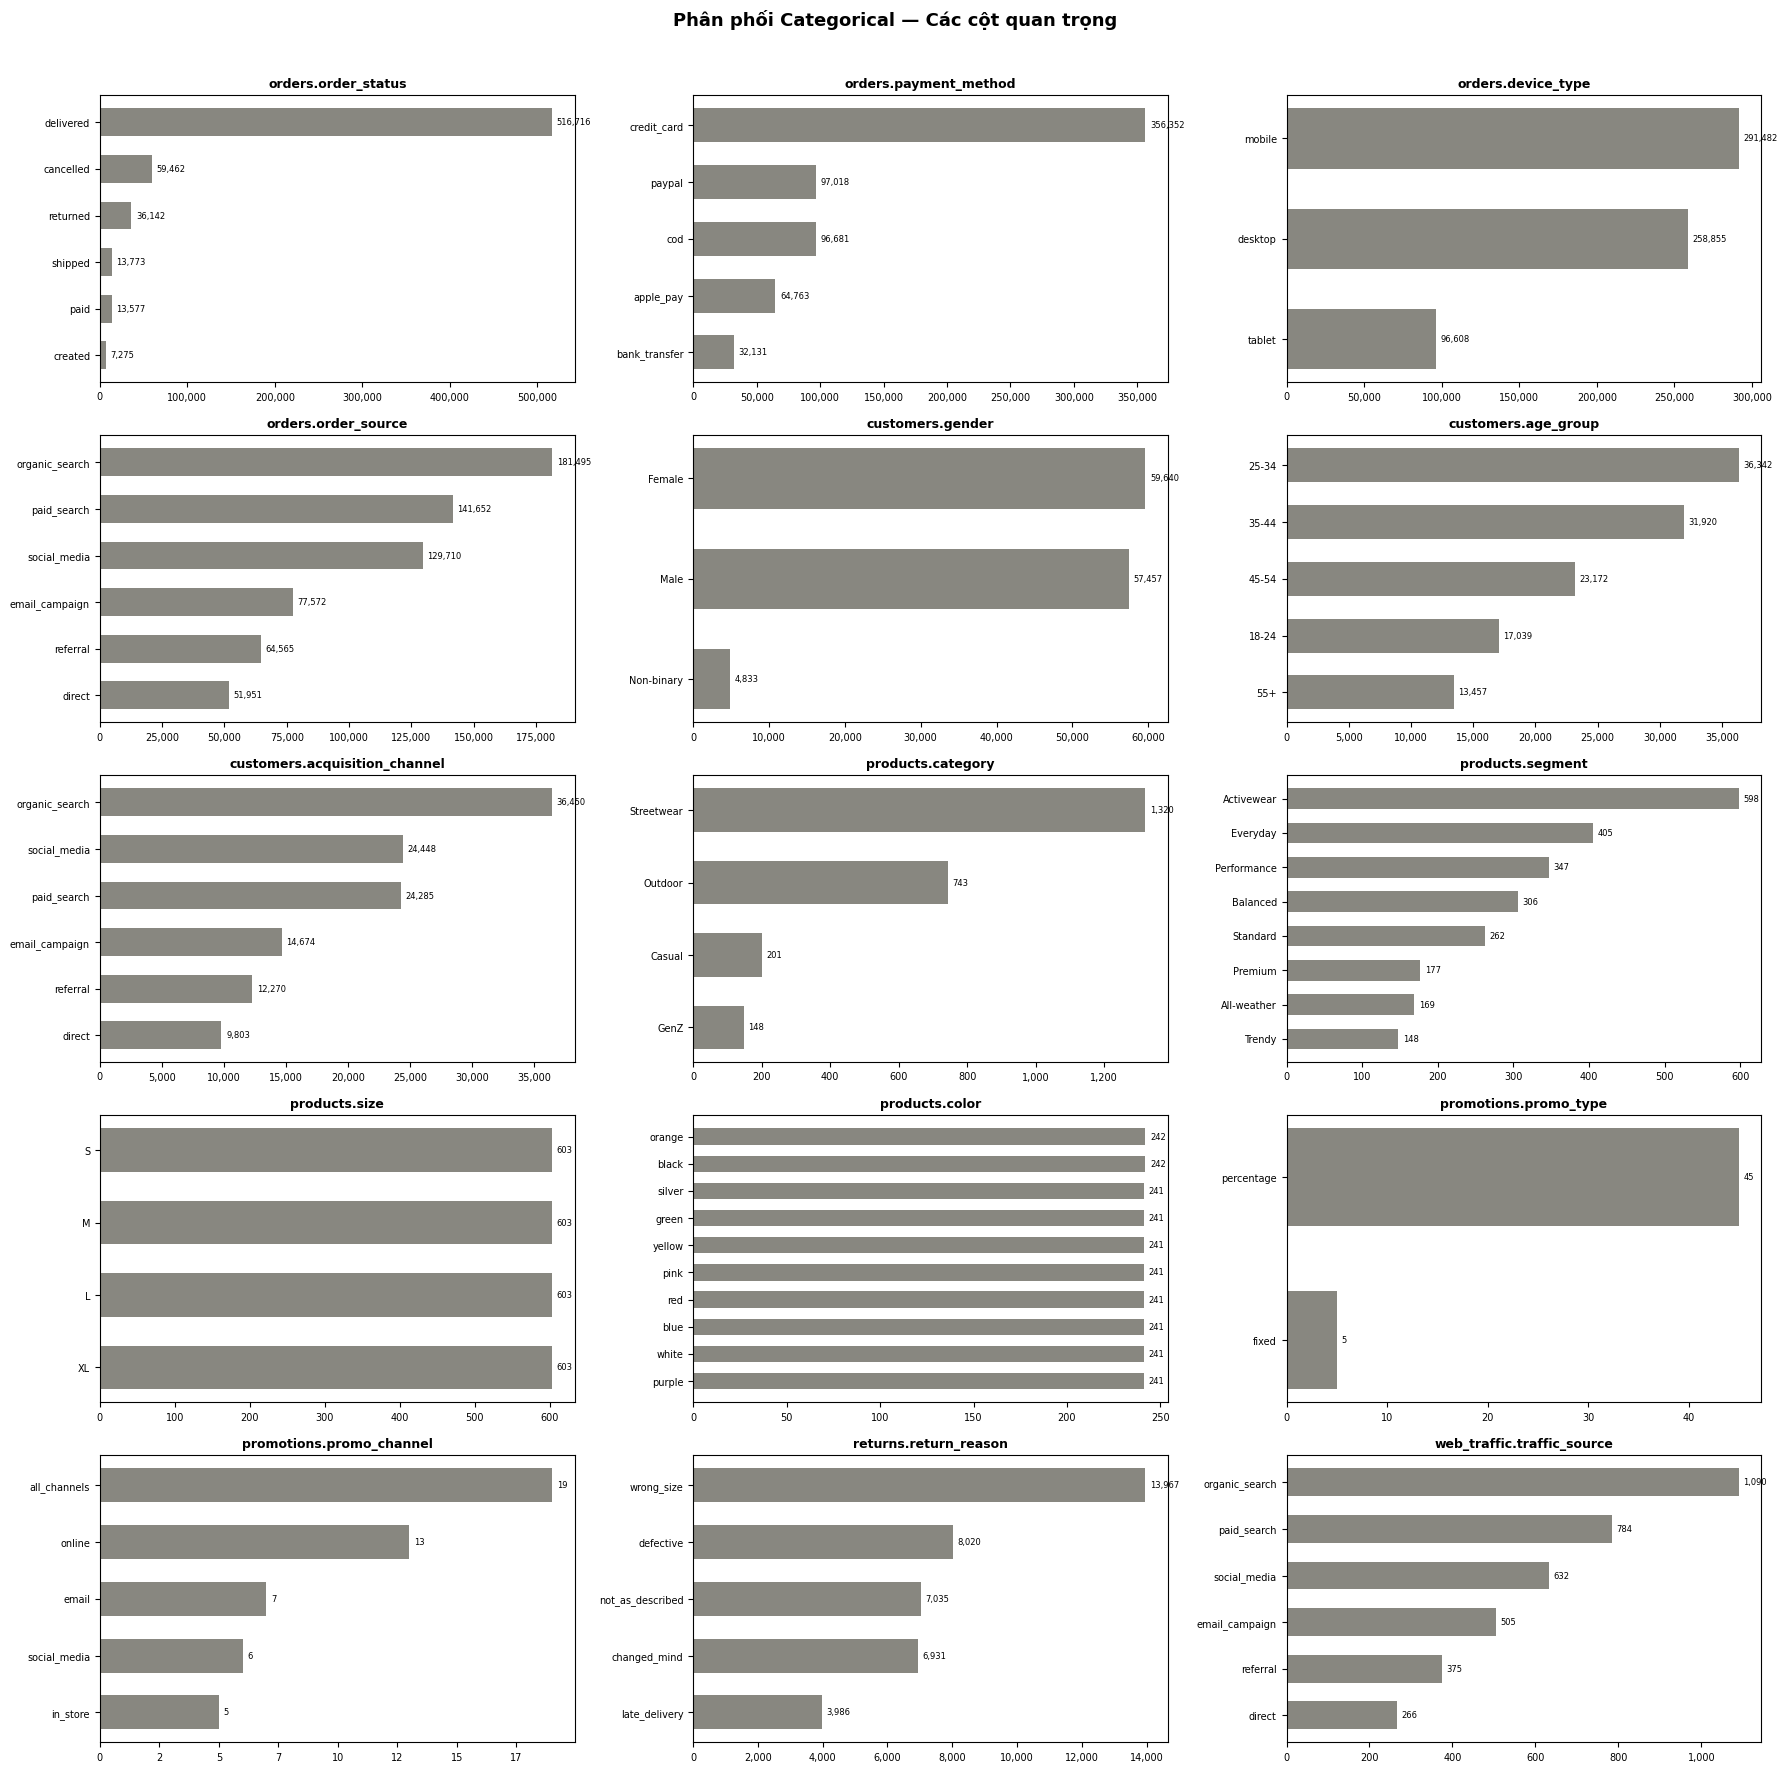

In [12]:
key_cats = {
    'orders'      : ['order_status', 'payment_method', 'device_type', 'order_source'],
    'customers'   : ['gender', 'age_group', 'acquisition_channel'],
    'products'    : ['category', 'segment', 'size', 'color'],
    'promotions'  : ['promo_type', 'promo_channel'],
    'returns'     : ['return_reason'],
    'web_traffic' : ['traffic_source'],
}

n_plots = sum(len(v) for v in key_cats.values())
fig, axes = plt.subplots(
    nrows=(n_plots + 2) // 3, ncols=3,
    figsize=(18, (n_plots + 2) // 3 * 3.5)
)
axes = axes.flatten()
idx  = 0

for tbl, cols in key_cats.items():
    if tbl not in dfs:
        continue
    df = dfs[tbl]
    for col in cols:
        if col not in df.columns:
            continue
        ax  = axes[idx]
        vc  = df[col].value_counts(dropna=False).head(12)
        bars = ax.barh(
            vc.index.astype(str), vc.values,
            color=COLOR_NEUTRAL, height=0.6
        )
        ax.invert_yaxis()
        ax.set_title(f'{tbl}.{col}', fontsize=9, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{int(x):,}'
        ))
        for bar, val in zip(bars, vc.values):
            ax.text(
                val + vc.values.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', ha='left', fontsize=6
            )
        idx += 1

for j in range(idx, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Phân phối Categorical — Các cột quan trọng', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Orders × Payments — Kiểm tra 1:1

In [13]:
if 'orders' in dfs and 'payments' in dfs:
    order_ids   = set(dfs['orders']['order_id'])
    payment_ids = set(dfs['payments']['order_id'])

    orders_no_payment = order_ids - payment_ids
    payments_no_order = payment_ids - order_ids

    flag1 = '🔴' if orders_no_payment else '✅'
    flag2 = '🔴' if payments_no_order else '✅'

    print(f'{flag1}  Orders không có payment record    : {len(orders_no_payment):,}')
    print(f'{flag2}  Payments không có order tương ứng : {len(payments_no_order):,}')

    # order_status vs payments
    if 'order_status' in dfs['orders'].columns:
        orders_df = dfs['orders'].copy()
        orders_df['has_payment'] = orders_df['order_id'].isin(payment_ids)
        cross = orders_df.groupby('order_status')['has_payment'].value_counts().unstack(fill_value=0)
        print('\nOrder status vs. payment exists:')
        print(cross)

✅  Orders không có payment record    : 0
✅  Payments không có order tương ứng : 0

Order status vs. payment exists:
has_payment     True
order_status        
cancelled      59462
created         7275
delivered     516716
paid           13577
returned       36142
shipped        13773


## 12. Sales — Target Variable Preview

Sales — describe:
                      Date     Revenue        COGS
count                 3833     3833.00     3833.00
mean   2017-10-02 00:00:00  4286584.03  3695134.49
min    2012-07-04 00:00:00   279813.94   236576.31
25%    2015-02-17 00:00:00  2471088.82  2150580.23
50%    2017-10-02 00:00:00  3647303.90  3161112.99
75%    2020-05-17 00:00:00  5350877.20  4637293.92
max    2022-12-31 00:00:00 20905271.35 16535857.67
std                    NaN  2624840.20  2219788.77


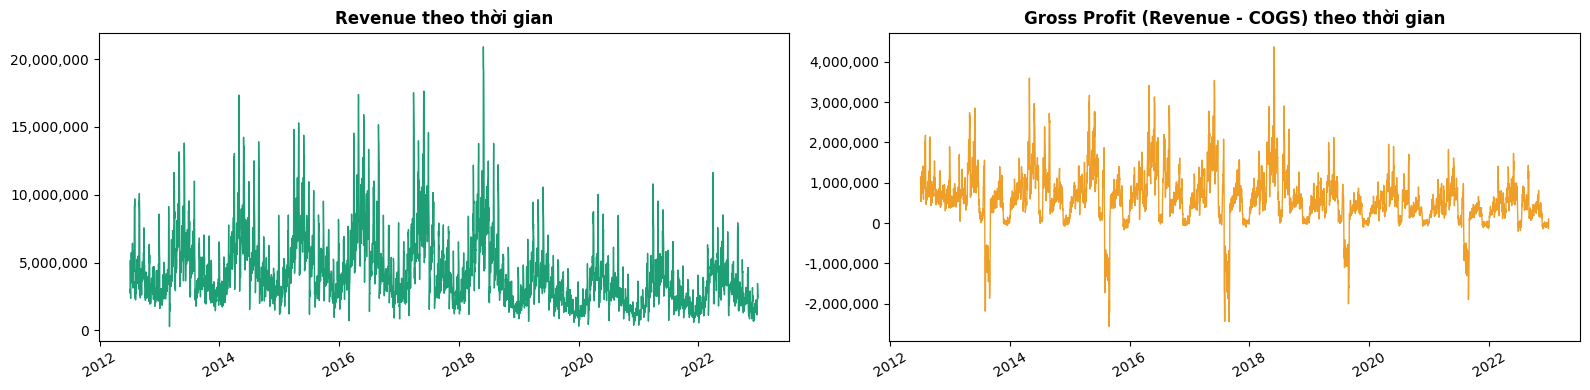

In [14]:
if 'sales' in dfs:
    df_sales = dfs['sales'].copy()
    date_col = 'Date' if 'Date' in df_sales.columns else df_sales.columns[0]
    df_sales[date_col] = pd.to_datetime(df_sales[date_col], errors='coerce')
    df_sales = df_sales.sort_values(date_col)

    print('Sales — describe:')
    print(df_sales.describe())

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    if 'Revenue' in df_sales.columns:
        axes[0].plot(df_sales[date_col], df_sales['Revenue'], color=COLOR_OK, linewidth=1)
        axes[0].set_title('Revenue theo thời gian', fontweight='bold')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    if 'Revenue' in df_sales.columns and 'COGS' in df_sales.columns:
        df_sales['GrossProfit'] = df_sales['Revenue'] - df_sales['COGS']
        axes[1].plot(df_sales[date_col], df_sales['GrossProfit'], color=COLOR_WARN, linewidth=1)
        axes[1].set_title('Gross Profit (Revenue - COGS) theo thời gian', fontweight='bold')
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.savefig('output_sales_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Tổng kết — Data Quality Score Card

In [15]:
print('\n' + '='*65)
print('📊  DATA QUALITY SCORE CARD')
print('='*65)

for name, df in dfs.items():
    total_cells  = df.shape[0] * df.shape[1]
    missing_pct  = df.isnull().sum().sum() / total_cells * 100
    dup_pct      = df.duplicated().sum() / len(df) * 100

    score = 100
    if missing_pct > 30: score -= 30
    elif missing_pct > 10: score -= 15
    elif missing_pct > 0: score -= 5
    if dup_pct > 5: score -= 20
    elif dup_pct > 0: score -= 5

    bar_len = int(score / 5)
    bar = '█' * bar_len + '░' * (20 - bar_len)
    grade = '🟢' if score >= 85 else '🟡' if score >= 60 else '🔴'
    print(f'  {grade}  {name:<22} [{bar}]  {score}/100  '
          f'(miss:{missing_pct:.1f}%  dup:{dup_pct:.2f}%)')

print('='*65)
print('\nHoàn tất! Check output_*.png để xem biểu đồ.')


📊  DATA QUALITY SCORE CARD
  🟢  products               [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  customers              [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  promotions             [███████████████████░]  95/100  (miss:8.0%  dup:0.00%)
  🟢  geography              [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  orders                 [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  order_items            [█████████████████░░░]  85/100  (miss:23.0%  dup:0.00%)
  🟢  payments               [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  shipments              [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  returns                [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  reviews                [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  inventory              [████████████████████]  100/100  (miss:0.0%  dup:0.00%)
  🟢  web_traffic            [████████████████████

In [1]:
# ============================================================
# SCHEMA CHECK — So sánh cột thực tế vs mô tả ban tổ chức
# ============================================================

EXPECTED_COLS = {
    'products'    : ['product_id','product_name','category','segment','size','color','price','cogs'],
    'customers'   : ['customer_id','zip','city','signup_date','gender','age_group','acquisition_channel'],
    'promotions'  : ['promo_id','promo_name','promo_type','discount_value','start_date','end_date',
                     'applicable_category','promo_channel','stackable_flag','min_order_value'],
    'geography'   : ['zip','city','region','district'],
    'orders'      : ['order_id','order_date','customer_id','zip','order_status',
                     'payment_method','device_type','order_source'],
    'order_items' : ['order_id','product_id','quantity','unit_price','discount_amount','promo_id','promo_id_2'],
    'payments'    : ['order_id','payment_method','payment_value','installments'],
    'shipments'   : ['order_id','ship_date','delivery_date','shipping_fee'],
    'returns'     : ['return_id','order_id','product_id','return_date','return_reason',
                     'return_quantity','refund_amount'],
    'reviews'     : ['review_id','order_id','product_id','customer_id','review_date','rating','review_title'],
    'inventory'   : ['snapshot_date','product_id','stock_on_hand','units_received','units_sold',
                     'stockout_days','days_of_supply','fill_rate','stockout_flag','overstock_flag',
                     'reorder_flag','sell_through_rate'],
    'web_traffic' : ['date','sessions','unique_visitors','page_views','bounce_rate',
                     'avg_session_duration_sec','conversion_rate','traffic_source'],
    'sales'       : ['Date','Revenue','COGS'],
    'sample_submission': ['Date','Revenue'],  # điều chỉnh nếu cần
}

print('='*70)
print(f"{'Table':<22} {'Status':<8} Chi tiết")
print('='*70)

all_ok = True
for name, expected in EXPECTED_COLS.items():
    if name not in dfs:
        print(f"⚠️  {name:<22} SKIP     (chưa load được)")
        continue

    actual   = list(dfs[name].columns)
    expected_set = set(c.lower() for c in expected)
    actual_set   = set(c.lower() for c in actual)

    missing_cols = expected_set - actual_set   # có trong mô tả nhưng không có trong file
    extra_cols   = actual_set - expected_set   # có trong file nhưng không có trong mô tả
    wrong_order  = (actual_set == expected_set) and (
                   [c.lower() for c in actual] != [c.lower() for c in expected])

    if not missing_cols and not extra_cols:
        print(f"✅  {name:<22} OK      ({len(actual)} cols)")
    else:
        all_ok = False
        print(f"🔴  {name:<22} LỆCH")
        if missing_cols:
            print(f"    ↳ Thiếu (trong mô tả nhưng file không có) : {sorted(missing_cols)}")
        if extra_cols:
            print(f"    ↳ Thừa  (file có nhưng mô tả không nhắc)  : {sorted(extra_cols)}")
        print(f"    ↳ Thực tế  : {actual}")
        print(f"    ↳ Mô tả BTC: {expected}")

print('='*70)
print("✅ Tất cả schema khớp!" if all_ok else "⚠️  Có bảng lệch schema — kiểm tra lại trước khi vẽ ERD.")

Table                  Status   Chi tiết


NameError: name 'dfs' is not defined

In [ ]:
# ============================================================
# MASTER DATA — Business Logic Validation
# Paste các cell này vào sau notebook 00_data_quality_check
# ============================================================

# ── CELL 1: products — Product Versioning Analysis ──────────
print("=" * 65)
print("📦 PRODUCTS — Kiểm tra Product Versioning")
print("=" * 65)

prod = dfs['products'].copy()

# Số product_id duy nhất vs số tổ hợp (name, size, color) duy nhất
n_ids        = prod['product_id'].nunique()
n_identity   = prod[['product_name','size','color']].drop_duplicates().shape[0]
n_duplicated = prod.duplicated(subset=['product_name','size','color'], keep=False).sum()

print(f"  Tổng product_id       : {n_ids:,}")
print(f"  Tổng (name,size,color): {n_identity:,}")
print(f"  Rows bị lặp identity  : {n_duplicated:,}  ({n_duplicated/n_ids*100:.1f}%)")
print()

# Top 10 mẫu hàng bị versioning nhiều nhất
dup_groups = (
    prod.groupby(['product_name','size','color'])
    .agg(n_versions=('product_id','count'),
         price_min=('price','min'),
         price_max=('price','max'),
         cogs_min=('cogs','min'),
         cogs_max=('cogs','max'))
    .query('n_versions > 1')
    .sort_values('n_versions', ascending=False)
)
print(f"  Số SKU có >1 version  : {len(dup_groups):,}")
print()
print("  Top 10 SKU nhiều version nhất:")
print(dup_groups.head(10).to_string())